# 🔍 Data Quality Assessment — Olist Dataset

Analisi di qualità dei dati per tutti i CSV Olist, eseguita in locale.

Ogni sezione analizza un singolo CSV e produce una **tabella scorecard DQ** con le dimensioni ISO 25012.

## ⚙️ Setup — Installazione librerie e import

In [1]:
import os
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ── PATH CONFIGURATION ────────────────────────────────────────────────────
# Il notebook si trova in consegna/2_scripts/
# I CSV raw sono in     consegna/1_raw_data/
# Le scorecard vanno in consegna/4_dq_scorecards/
# I plot vanno in       consegna/5_dq_plots/

_HERE = os.path.dirname(os.path.abspath('__file__'))  # consegna/2_scripts/
_ROOT = os.path.dirname(_HERE)                         # consegna/

RAW_PATH  = os.path.join(_ROOT, '1_raw_data')  + os.sep
BASE_PATH = os.path.join(_ROOT, '4_dq_scorecards') + os.sep
PLOT_PATH = os.path.join(_ROOT, '5_dq_plots')  + os.sep

os.makedirs(BASE_PATH, exist_ok=True)
os.makedirs(PLOT_PATH, exist_ok=True)

print('✅ Path configurati:')
print(f'   RAW_PATH  = {RAW_PATH}')
print(f'   BASE_PATH = {BASE_PATH}')
print(f'   PLOT_PATH = {PLOT_PATH}')

# Verifica che i CSV esistano
csv_files = [f for f in os.listdir(RAW_PATH) if f.endswith('.csv')]
print(f'\n📂 CSV trovati in RAW_PATH: {len(csv_files)}')
for f in sorted(csv_files):
    print(f'   {f}')


✅ Path configurati:
   RAW_PATH  = c:\Users\ecole\Downloads\provaaa\consegna\1_raw_data\
   BASE_PATH = c:\Users\ecole\Downloads\provaaa\consegna\4_dq_scorecards\
   PLOT_PATH = c:\Users\ecole\Downloads\provaaa\consegna\5_dq_plots\

📂 CSV trovati in RAW_PATH: 9
   olist_customers_dataset.csv
   olist_geolocation_dataset.csv
   olist_order_items_dataset.csv
   olist_order_payments_dataset.csv
   olist_order_reviews_dataset.csv
   olist_orders_dataset.csv
   olist_products_dataset.csv
   olist_sellers_dataset.csv
   product_category_name_translation.csv


## 🏗️ Classe DQAReport — motore di valutazione

In [2]:
class DQAReport:
    """
    Structured, repeatable Data Quality Assessment Report.
    Valuta le dimensioni ISO 25012: Completeness, Uniqueness, Validity,
    Consistency, Precision e produce uno scorecard strutturato.
    """

    def __init__(self, df: pd.DataFrame, table_name: str, primary_key: str = None):
        self.df         = df.copy()
        self.table_name = table_name
        self.pk         = primary_key
        self.results    = {}   # dimension -> {'score', 'issues', 'details'}
        self.flags      = {}   # dimension -> boolean Series (True = issue)

    # ── COMPLETENESS ──────────────────────────────────────────────────────
    def check_completeness(self, required_cols: list = None):
        cols          = required_cols or self.df.columns.tolist()
        # Filtra le colonne che esistono davvero nel dataframe
        cols          = [c for c in cols if c in self.df.columns]
        missing_counts = self.df[cols].isnull().sum()
        total_values   = len(self.df) * len(cols)
        total_missing  = missing_counts.sum()
        score          = 1 - (total_missing / total_values) if total_values > 0 else 1.0
        flag_rows      = self.df[cols].isnull().any(axis=1)
        self.flags['completeness'] = flag_rows
        self.results['completeness'] = {
            'score'  : round(score, 4),
            'issues' : int(total_missing),
            'details': f"Missing per col: {missing_counts[missing_counts > 0].to_dict()}"
        }
        return self

    # ── UNIQUENESS ────────────────────────────────────────────────────────
    def check_uniqueness(self, key_cols: list = None):
        cols  = key_cols or ([self.pk] if self.pk else self.df.columns.tolist())
        cols  = [c for c in cols if c in self.df.columns]
        dup   = self.df.duplicated(subset=cols, keep=False)
        score = 1 - (dup.sum() / len(self.df))
        self.flags['uniqueness'] = dup
        self.results['uniqueness'] = {
            'score'  : round(score, 4),
            'issues' : int(dup.sum()),
            'details': f"Righe duplicate su {cols}: {int(dup.sum())}"
        }
        return self

    # ── VALIDITY ──────────────────────────────────────────────────────────
    def check_validity(self, rules: dict):
        """rules: {col_name: callable -> bool Series}  (True = valido)"""
        all_invalid  = pd.Series(False, index=self.df.index)
        rule_details = []
        for col, rule_fn in rules.items():
            if col not in self.df.columns:
                continue
            valid_mask   = rule_fn(self.df[col])
            invalid_mask = ~valid_mask & self.df[col].notna()
            all_invalid |= invalid_mask
            rule_details.append(f"{col}: {int(invalid_mask.sum())} invalid")
        score = 1 - (all_invalid.sum() / len(self.df))
        self.flags['validity'] = all_invalid
        self.results['validity'] = {
            'score'  : round(score, 4),
            'issues' : int(all_invalid.sum()),
            'details': " | ".join(rule_details) if rule_details else "Nessuna regola applicata"
        }
        return self

    # ── CONSISTENCY ───────────────────────────────────────────────────────
    def check_consistency(self, rules: list):
        """rules: list of callables df -> bool Series  (True = consistente)"""
        all_inconsistent = pd.Series(False, index=self.df.index)
        for rule_fn in rules:
            all_inconsistent |= ~rule_fn(self.df)
        score = 1 - (all_inconsistent.sum() / len(self.df))
        self.flags['consistency'] = all_inconsistent
        self.results['consistency'] = {
            'score'  : round(score, 4),
            'issues' : int(all_inconsistent.sum()),
            'details': f"{int(all_inconsistent.sum())} righe violano almeno una regola di consistenza"
        }
        return self

    # ── PRECISION ────────────────────────────────────────────────────────────
    def check_precision(self, num_col: str = None, k: float = 3.0):
        """Precision: % of correct (non-outlier) data values.
        Per colonne numeriche: flag valori fuori da media \u00b1 k*std.
        Basato su data profiling variance/deviation (slide 27).
        """
        if num_col and num_col in self.df.columns:
            col      = self.df[num_col].dropna()
            mean_val = col.mean()
            std_val  = col.std()
            lower = mean_val - k * std_val
            upper = mean_val + k * std_val
            flag  = (self.df[num_col] < lower) | (self.df[num_col] > upper)
            flag  = flag.fillna(False)
            score = 1 - (flag.sum() / len(self.df))
            self.flags['precision'] = flag
            self.results['precision'] = {
                'score'  : round(score, 4),
                'issues' : int(flag.sum()),
                'details': f"Variance \u00b1{k}\u03c3: mean={mean_val:.2f}, std={std_val:.2f}, range=[{lower:.2f}, {upper:.2f}]"
            }
        else:
            self.flags['precision'] = pd.Series(False, index=self.df.index)
            self.results['precision'] = {
                'score'  : 1.0,
                'issues' : 0,
                'details': 'No numeric col specified – precision assumed 100%'
            }
        return self

    # ── SCORECARD ─────────────────────────────────────────────────────────
    def scorecard(self) -> pd.DataFrame:
        rows = []
        for dim, res in self.results.items():
            emoji = '🟢' if res['score'] >= 0.95 else ('🟡' if res['score'] >= 0.80 else '🔴')
            rows.append({
                'Table'    : self.table_name,
                'Dimension': dim.capitalize(),
                'Score'    : res['score'],
                'Issues'   : res['issues'],
                'Status'   : emoji,
                'Details'  : res['details']
            })
        return pd.DataFrame(rows)

    def overall_score(self) -> float:
        if not self.results:
            return 0.0
        return round(float(np.mean([v['score'] for v in self.results.values()])), 4)

    def print_scorecard(self):
        sc = self.scorecard()
        overall = self.overall_score()
        emoji_overall = '🟢' if overall >= 0.95 else ('🟡' if overall >= 0.80 else '🔴')
        print(f"\n{'═'*70}")
        print(f"  📊 {self.table_name.upper()}  —  Overall DQ Score: {overall:.2%} {emoji_overall}")
        print(f"{'═'*70}")
        print(sc[['Dimension','Score','Issues','Status','Details']].to_string(index=False))
        print(f"{'─'*70}\n")
        return sc

def plot_scorecard(dqa: DQAReport, df: pd.DataFrame, save_path: str = None):
    """Visualizza la missing-matrix e il bar chart dei DQ scores."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Missing values matrix
    msno.matrix(df, ax=axes[0], color=(0.25, 0.45, 0.75), fontsize=9)
    axes[0].set_title(f'Missing Values Matrix — {dqa.table_name}', fontsize=11, fontweight='bold')
    # DQ Score bar chart
    sc     = dqa.scorecard()
    colors = ['#2ecc71' if s >= 0.95 else ('#f39c12' if s >= 0.80 else '#e74c3c') for s in sc['Score']]
    axes[1].barh(sc['Dimension'], sc['Score'], color=colors, edgecolor='white', height=0.5)
    axes[1].set_xlim(0, 1.12)
    axes[1].axvline(0.95, color='green',  linestyle='--', alpha=0.5, label='Target ≥ 0.95')
    axes[1].axvline(0.80, color='orange', linestyle='--', alpha=0.5, label='Warning ≥ 0.80')
    for i, (score, dim) in enumerate(zip(sc['Score'], sc['Dimension'])):
        axes[1].text(score + 0.01, i, f'{score:.2%}', va='center', fontsize=9)
    axes[1].set_title(f'DQ Dimension Scores — {dqa.table_name}', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Score (0–1)')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'   📁 Plot salvato → {save_path}')
    plt.show()

print('✅ DQAReport class e funzioni di utilità definite')


✅ DQAReport class e funzioni di utilità definite


---
## 1️⃣ `olist_orders_dataset.csv`

Colonne: `order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`

In [3]:
df_orders = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')
print(f'Shape: {df_orders.shape}')
print(f'Colonne: {df_orders.columns.tolist()}')
df_orders.head(3)


Shape: (99441, 8)
Colonne: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



══════════════════════════════════════════════════════════════════════
  📊 OLIST_ORDERS  —  Overall DQ Score: 99.27% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                                  Details
Completeness 0.9938    4908      🟢 Missing per col: {'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965}
  Uniqueness 1.0000       0      🟢                                                                                       Righe duplicate su ['order_id']: 0
    Validity 1.0000       0      🟢             order_id: 0 invalid | customer_id: 0 invalid | order_status: 0 invalid | order_purchase_timestamp: 0 invalid
 Consistency 0.9698    3003      🟢                                                                      3003 righe violano almeno una regola di consistenza
   Precision 1.0000       0  

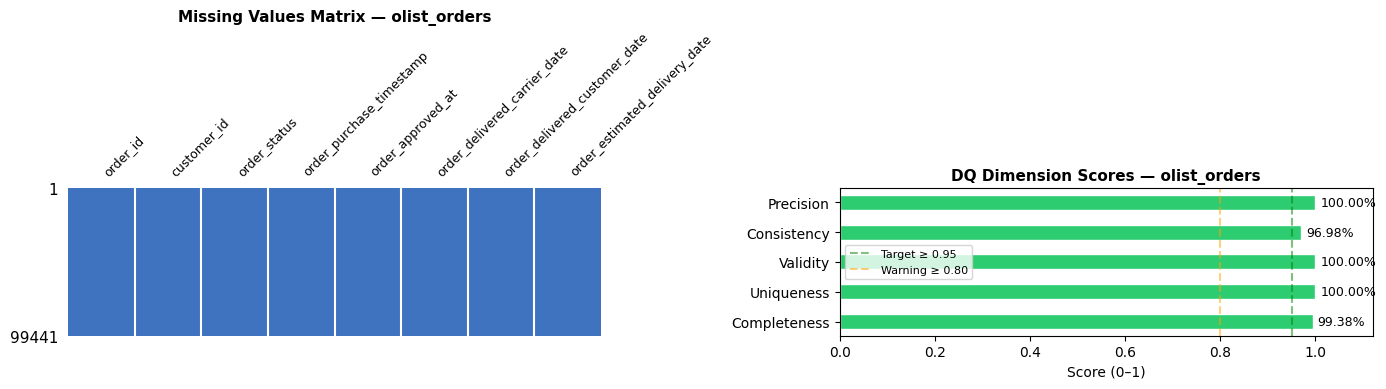

In [4]:
VALID_STATUSES = ['delivered','shipped','canceled','invoiced','processing',
                  'approved','created','unavailable']

validity_orders = {
    'order_id'                    : lambda s: s.str.len() == 32,
    'customer_id'                 : lambda s: s.str.len() == 32,
    'order_status'                : lambda s: s.isin(VALID_STATUSES),
    'order_purchase_timestamp'    : lambda s: pd.to_datetime(s, errors='coerce').notna(),
}

consistency_orders = [
    # approved_at deve essere >= purchase_timestamp
    lambda df: (
        pd.to_datetime(df['order_approved_at'], errors='coerce') >=
        pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
    ).fillna(True),  # NaN approvazione → considerata consistente (non approvato ancora)
    # delivered_customer_date >= delivered_carrier_date
    lambda df: (
        pd.to_datetime(df['order_delivered_customer_date'], errors='coerce') >=
        pd.to_datetime(df['order_delivered_carrier_date'],  errors='coerce')
    ).fillna(True),
    # estimated_delivery >= purchase_timestamp
    lambda df: (
        pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce') >=
        pd.to_datetime(df['order_purchase_timestamp'],      errors='coerce')
    ).fillna(True),
]

dqa_orders = (
    DQAReport(df_orders, table_name='olist_orders', primary_key='order_id')
    .check_completeness(required_cols=df_orders.columns.tolist())
    .check_uniqueness(key_cols=['order_id'])
    .check_validity(validity_orders)
    .check_consistency(consistency_orders)
    .check_precision()
)

sc_orders = dqa_orders.print_scorecard()
plot_scorecard(dqa_orders, df_orders, save_path=PLOT_PATH + 'dq_plot_orders.png')
sc_orders.to_csv(BASE_PATH + 'dq_scorecard_orders.csv', index=False)


---
## 2️⃣ `olist_customers_dataset.csv`

Colonne: `customer_id`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, `customer_state`

In [5]:
df_customers = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')
print(f'Shape: {df_customers.shape}')
print(f'Colonne: {df_customers.columns.tolist()}')
df_customers.head(3)


Shape: (99441, 5)
Colonne: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



══════════════════════════════════════════════════════════════════════
  📊 OLIST_CUSTOMERS  —  Overall DQ Score: 93.97% 🟡
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                                      Details
Completeness 1.0000       0      🟢                                                                                                          Missing per col: {}
  Uniqueness 1.0000       0      🟢                                                                                        Righe duplicate su ['customer_id']: 0
    Validity 0.7587   23995      🔴 customer_id: 0 invalid | customer_unique_id: 0 invalid | customer_zip_code_prefix: 23995 invalid | customer_state: 0 invalid
 Consistency 1.0000       0      🟢                                                                             0 righe violano almeno una regola di consistenza
──────

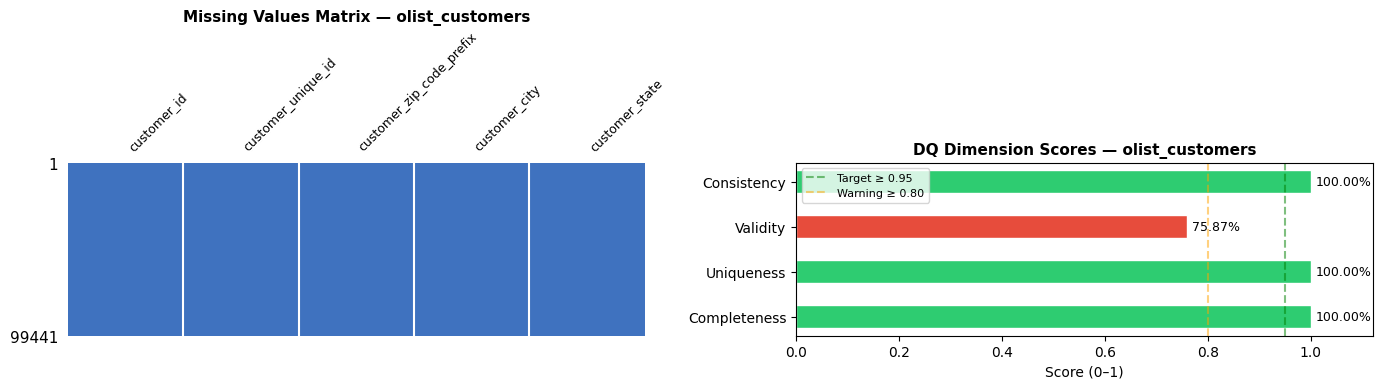

In [6]:
# Codici stato brasiliani validi (2 lettere maiuscole)
BR_STATES = ['AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG',
             'PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO']

validity_customers = {
    'customer_id'            : lambda s: s.str.len() == 32,
    'customer_unique_id'     : lambda s: s.str.len() == 32,
    'customer_zip_code_prefix': lambda s: s.astype(str).str.match(r'^\d{5}$'),
    'customer_state'         : lambda s: s.isin(BR_STATES),
}

consistency_customers = [
    # customer_id univoco
    lambda df: ~df.duplicated(subset=['customer_id'], keep=False),
]

dqa_customers = (
    DQAReport(df_customers, table_name='olist_customers', primary_key='customer_id')
    .check_completeness(required_cols=df_customers.columns.tolist())
    .check_uniqueness(key_cols=['customer_id'])
    .check_validity(validity_customers)
    .check_consistency(consistency_customers)
)

sc_customers = dqa_customers.print_scorecard()
plot_scorecard(dqa_customers, df_customers, save_path=PLOT_PATH + 'dq_plot_customers.png')
sc_customers.to_csv(BASE_PATH + 'dq_scorecard_customers.csv', index=False)


---
## 3️⃣ `olist_order_items_dataset.csv`

Colonne: `order_id`, `order_item_id`, `product_id`, `seller_id`, `shipping_limit_date`, `price`, `freight_value`

In [7]:
df_items = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')
print(f'Shape: {df_items.shape}')
print(f'Colonne: {df_items.columns.tolist()}')
df_items.head(3)


Shape: (112650, 7)
Colonne: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700



══════════════════════════════════════════════════════════════════════
  📊 OLIST_ORDER_ITEMS  —  Overall DQ Score: 99.65% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                 Details
Completeness 1.0000       0      🟢                                                                                     Missing per col: {}
  Uniqueness 1.0000       0      🟢                                                     Righe duplicate su ['order_id', 'order_item_id']: 0
    Validity 1.0000       0      🟢 price: 0 invalid | freight_value: 0 invalid | order_item_id: 0 invalid | shipping_limit_date: 0 invalid
 Consistency 1.0000       0      🟢                                                        0 righe violano almeno una regola di consistenza
   Precision 0.9825    1966      🟢                                        Variance ±3.0σ: mean=120.65, std=18

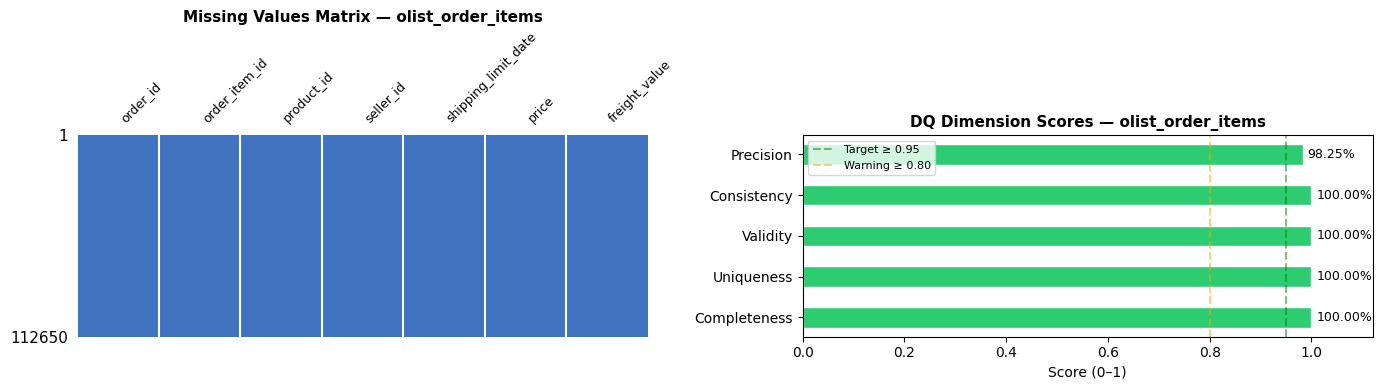

In [8]:
validity_items = {
    'price'         : lambda s: s > 0,
    'freight_value' : lambda s: s >= 0,
    'order_item_id' : lambda s: s >= 1,
    'shipping_limit_date': lambda s: pd.to_datetime(s, errors='coerce').notna(),
}

consistency_items = [
    # price + freight_value = totale ragionevole (entrambi non negativi insieme)
    lambda df: (df['price'] > 0) & (df['freight_value'] >= 0),
    # order_item_id deve essere ≥ 1
    lambda df: df['order_item_id'] >= 1,
]

dqa_items = (
    DQAReport(df_items, table_name='olist_order_items', primary_key=None)
    .check_completeness(required_cols=df_items.columns.tolist())
    .check_uniqueness(key_cols=['order_id', 'order_item_id'])
    .check_validity(validity_items)
    .check_consistency(consistency_items)
    .check_precision('price')
)

sc_items = dqa_items.print_scorecard()
plot_scorecard(dqa_items, df_items, save_path=PLOT_PATH + 'dq_plot_order_items.png')
sc_items.to_csv(BASE_PATH + 'dq_scorecard_order_items.csv', index=False)


---
## 4️⃣ `olist_order_payments_dataset.csv`

Colonne: `order_id`, `payment_sequential`, `payment_type`, `payment_installments`, `payment_value`

In [9]:
df_payments = pd.read_csv(RAW_PATH + 'olist_order_payments_dataset.csv')
print(f'Shape: {df_payments.shape}')
print(f'Colonne: {df_payments.columns.tolist()}')
df_payments.head(3)


Shape: (103886, 5)
Colonne: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.3300
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.3900
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.7100



══════════════════════════════════════════════════════════════════════
  📊 OLIST_ORDER_PAYMENTS  —  Overall DQ Score: 99.65% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                              Details
Completeness 1.0000       0      🟢                                                                                                  Missing per col: {}
  Uniqueness 1.0000       0      🟢                                                             Righe duplicate su ['order_id', 'payment_sequential']: 0
    Validity 1.0000       0      🟢 payment_type: 0 invalid | payment_value: 0 invalid | payment_installments: 0 invalid | payment_sequential: 0 invalid
 Consistency 1.0000       2      🟢                                                                     2 righe violano almeno una regola di consistenza
   Precision 0.9826    1803      🟢       

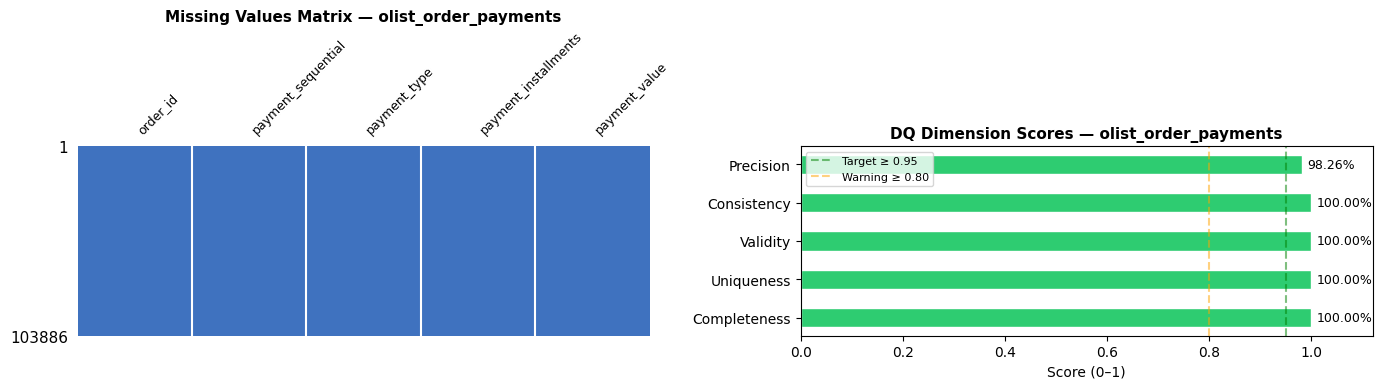

In [10]:
VALID_PAYMENT_TYPES = ['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']

validity_payments = {
    'payment_type'         : lambda s: s.isin(VALID_PAYMENT_TYPES),
    'payment_value'        : lambda s: s >= 0,
    'payment_installments' : lambda s: s >= 0,
    'payment_sequential'   : lambda s: s >= 1,
}

consistency_payments = [
    # payment_value > 0 oppure payment_type è voucher (può essere 0)
    lambda df: (df['payment_value'] >= 0),
    # installments == 0 solo se non è carta di credito
    lambda df: ~((df['payment_type'] == 'credit_card') & (df['payment_installments'] == 0)),
]

dqa_payments = (
    DQAReport(df_payments, table_name='olist_order_payments')
    .check_completeness(required_cols=df_payments.columns.tolist())
    .check_uniqueness(key_cols=['order_id', 'payment_sequential'])
    .check_validity(validity_payments)
    .check_consistency(consistency_payments)
    .check_precision('payment_value')  
)

sc_payments = dqa_payments.print_scorecard()
plot_scorecard(dqa_payments, df_payments, save_path=PLOT_PATH + 'dq_plot_order_payments.png')
sc_payments.to_csv(BASE_PATH + 'dq_scorecard_order_payments.csv', index=False)


---
## 5️⃣ `olist_order_reviews_dataset.csv`

Colonne: `review_id`, `order_id`, `review_score`, `review_comment_title`, `review_comment_message`, `review_creation_date`, `review_answer_timestamp`

In [11]:
df_reviews = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')
print(f'Shape: {df_reviews.shape}')
print(f'Colonne: {df_reviews.columns.tolist()}')
df_reviews.head(3)


Shape: (99224, 7)
Colonne: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24



══════════════════════════════════════════════════════════════════════
  📊 OLIST_ORDER_REVIEWS  —  Overall DQ Score: 99.68% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                                                     Details
Completeness 1.0000       0      🟢                                                                                                                         Missing per col: {}
  Uniqueness 0.9838    1603      🟢                                                                                                      Righe duplicate su ['review_id']: 1603
    Validity 1.0000       0      🟢 review_score: 0 invalid | review_id: 0 invalid | order_id: 0 invalid | review_creation_date: 0 invalid | review_answer_timestamp: 0 invalid
 Consistency 1.0000       0      🟢                                                                    

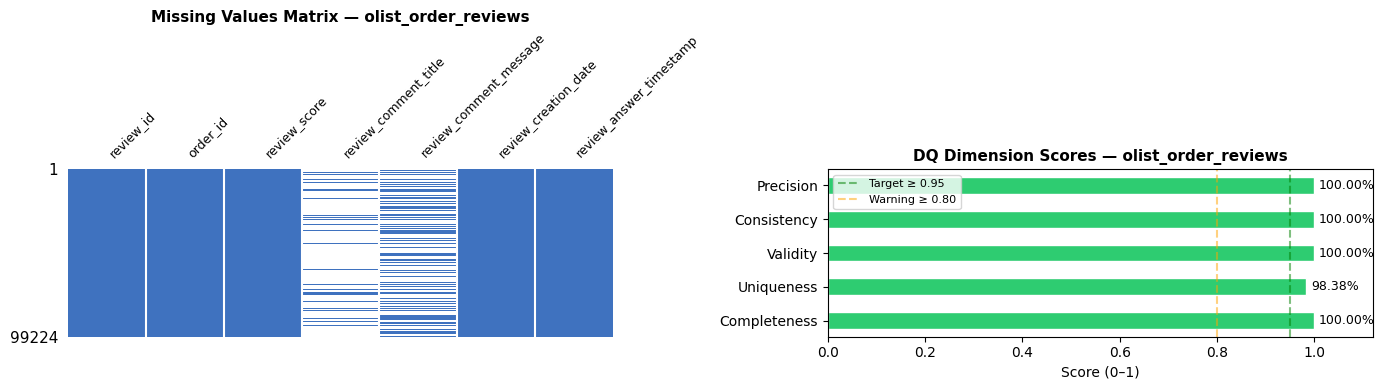

In [12]:
validity_reviews = {
    'review_score'    : lambda s: s.between(1, 5),
    'review_id'       : lambda s: s.str.len() == 32,
    'order_id'        : lambda s: s.str.len() == 32,
    'review_creation_date'    : lambda s: pd.to_datetime(s, errors='coerce').notna(),
    'review_answer_timestamp' : lambda s: pd.to_datetime(s, errors='coerce').notna(),
}

consistency_reviews = [
    # answer_timestamp >= creation_date
    lambda df: (
        pd.to_datetime(df['review_answer_timestamp'], errors='coerce') >=
        pd.to_datetime(df['review_creation_date'],    errors='coerce')
    ).fillna(True),
]

dqa_reviews = (
    DQAReport(df_reviews, table_name='olist_order_reviews', primary_key='review_id')
    .check_completeness(required_cols=['review_id','order_id','review_score','review_creation_date','review_answer_timestamp'])
    .check_uniqueness(key_cols=['review_id'])
    .check_validity(validity_reviews)
    .check_consistency(consistency_reviews)
    .check_precision('review_score')
)

sc_reviews = dqa_reviews.print_scorecard()
plot_scorecard(dqa_reviews, df_reviews, save_path=PLOT_PATH + 'dq_plot_order_reviews.png')
sc_reviews.to_csv(BASE_PATH + 'dq_scorecard_order_reviews.csv', index=False)


---
## 6️⃣ `olist_products_dataset.csv`

Colonne: `product_id`, `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`

In [13]:
df_products = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')
print(f'Shape: {df_products.shape}')
print(f'Colonne: {df_products.columns.tolist()}')
df_products.head(3)


Shape: (32951, 9)
Colonne: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0000,287.0000,1.0000,225.0000,16.0000,10.0000,14.0000
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0000,276.0000,1.0000,1000.0000,30.0000,18.0000,20.0000
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0000,250.0000,1.0000,154.0000,18.0000,9.0000,15.0000



══════════════════════════════════════════════════════════════════════
  📊 OLIST_PRODUCTS  —  Overall DQ Score: 99.25% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                                                                                                                                                 Details
Completeness 0.9917    2448      🟢 Missing per col: {'product_category_name': 610, 'product_name_lenght': 610, 'product_description_lenght': 610, 'product_photos_qty': 610, 'product_weight_g': 2, 'product_length_cm': 2, 'product_height_cm': 2, 'product_width_cm': 2}
  Uniqueness 1.0000       0      🟢                                                                                                                                                                                                    Righe duplicate su ['product_id']: 0
    Va

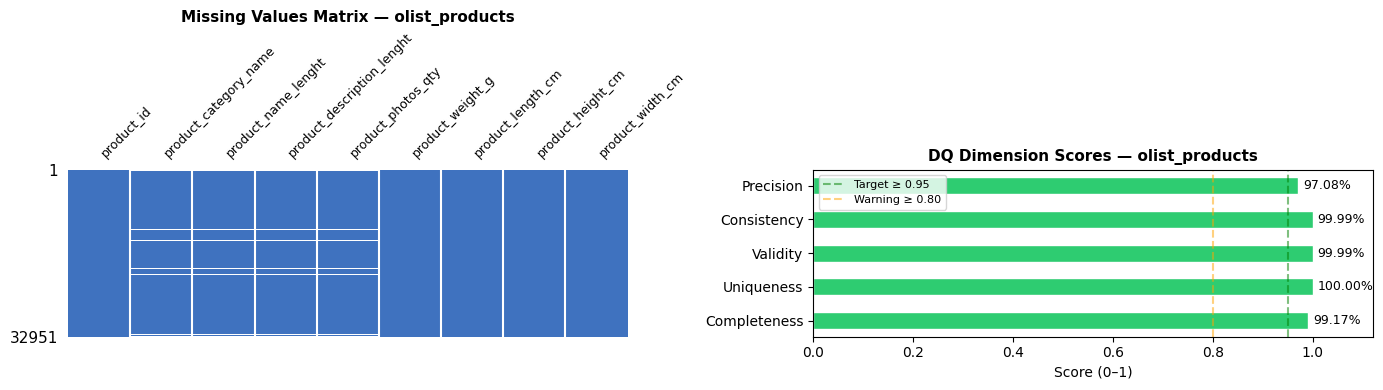

In [14]:
validity_products = {
    'product_weight_g'           : lambda s: s > 0,
    'product_length_cm'          : lambda s: s > 0,
    'product_height_cm'          : lambda s: s > 0,
    'product_width_cm'           : lambda s: s > 0,
    'product_photos_qty'         : lambda s: s >= 0,
    'product_name_lenght'        : lambda s: s > 0,
    'product_description_lenght' : lambda s: s > 0,
}

consistency_products = [
    # volume calcolabile (tutte le dimensioni presenti e positive)
    lambda df: (
        df['product_length_cm'].notna() &
        df['product_height_cm'].notna() &
        df['product_width_cm'].notna()
    ),
]

dqa_products = (
    DQAReport(df_products, table_name='olist_products', primary_key='product_id')
    .check_completeness(required_cols=df_products.columns.tolist())
    .check_uniqueness(key_cols=['product_id'])
    .check_validity(validity_products)
    .check_consistency(consistency_products)
    .check_precision('product_weight_g')
)

sc_products = dqa_products.print_scorecard()
plot_scorecard(dqa_products, df_products, save_path=PLOT_PATH + 'dq_plot_products.png')
sc_products.to_csv(BASE_PATH + 'dq_scorecard_products.csv', index=False)


---
## 7️⃣ `olist_sellers_dataset.csv`

Colonne: `seller_id`, `seller_zip_code_prefix`, `seller_city`, `seller_state`

In [15]:
df_sellers = pd.read_csv(RAW_PATH + 'olist_sellers_dataset.csv')
print(f'Shape: {df_sellers.shape}')
print(f'Colonne: {df_sellers.columns.tolist()}')
df_sellers.head(3)


Shape: (3095, 4)
Colonne: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



══════════════════════════════════════════════════════════════════════
  📊 OLIST_SELLERS  —  Overall DQ Score: 91.71% 🟡
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                               Details
Completeness 1.0000       0      🟢                                                                   Missing per col: {}
  Uniqueness 1.0000       0      🟢                                                   Righe duplicate su ['seller_id']: 0
    Validity 0.6682    1027      🔴 seller_id: 0 invalid | seller_zip_code_prefix: 1027 invalid | seller_state: 0 invalid
 Consistency 1.0000       0      🟢                                      0 righe violano almeno una regola di consistenza
──────────────────────────────────────────────────────────────────────

   📁 Plot salvato → c:\Users\ecole\Downloads\provaaa\consegna\5_dq_plots\dq_plot_sellers.png


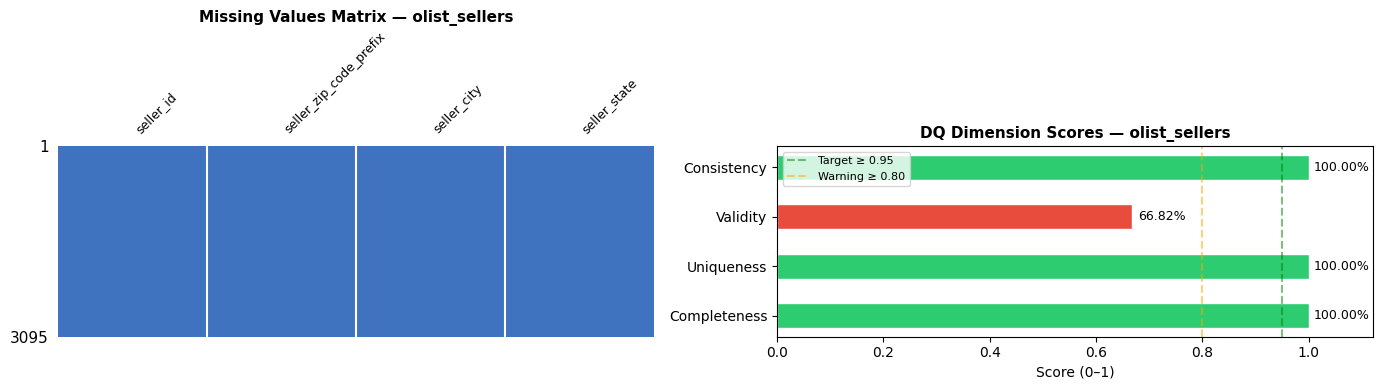

In [16]:
BR_STATES = ['AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG',
             'PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO']

validity_sellers = {
    'seller_id'              : lambda s: s.str.len() == 32,
    'seller_zip_code_prefix' : lambda s: s.astype(str).str.match(r'^\d{5}$'),
    'seller_state'           : lambda s: s.isin(BR_STATES),
}

consistency_sellers = [
    lambda df: ~df.duplicated(subset=['seller_id'], keep=False),
]

dqa_sellers = (
    DQAReport(df_sellers, table_name='olist_sellers', primary_key='seller_id')
    .check_completeness(required_cols=df_sellers.columns.tolist())
    .check_uniqueness(key_cols=['seller_id'])
    .check_validity(validity_sellers)
    .check_consistency(consistency_sellers)
)

sc_sellers = dqa_sellers.print_scorecard()
plot_scorecard(dqa_sellers, df_sellers, save_path=PLOT_PATH + 'dq_plot_sellers.png')
sc_sellers.to_csv(BASE_PATH + 'dq_scorecard_sellers.csv', index=False)


---
## 8️⃣ `olist_geolocation_dataset.csv`

Colonne: `geolocation_zip_code_prefix`, `geolocation_lat`, `geolocation_lng`, `geolocation_city`, `geolocation_state`

In [17]:
df_geo = pd.read_csv(RAW_PATH + 'olist_geolocation_dataset.csv')
print(f'Shape: {df_geo.shape}')
print(f'Colonne: {df_geo.columns.tolist()}')
df_geo.head(3)


Shape: (1000163, 5)
Colonne: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.5456,-46.6393,sao paulo,SP
1,1046,-23.5461,-46.6448,sao paulo,SP
2,1046,-23.5461,-46.6430,sao paulo,SP



══════════════════════════════════════════════════════════════════════
  📊 OLIST_GEOLOCATION  —  Overall DQ Score: 68.88% 🔴
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                                                                                Details
Completeness 1.0000       0      🟢                                                                                                                    Missing per col: {}
  Uniqueness 0.0010  999120      🔴                                                                             Righe duplicate su ['geolocation_zip_code_prefix']: 999120
    Validity 0.7543  245775      🔴 geolocation_zip_code_prefix: 245733 invalid | geolocation_lat: 31 invalid | geolocation_lng: 37 invalid | geolocation_state: 0 invalid
 Consistency 1.0000       0      🟢                                                                                       0 r

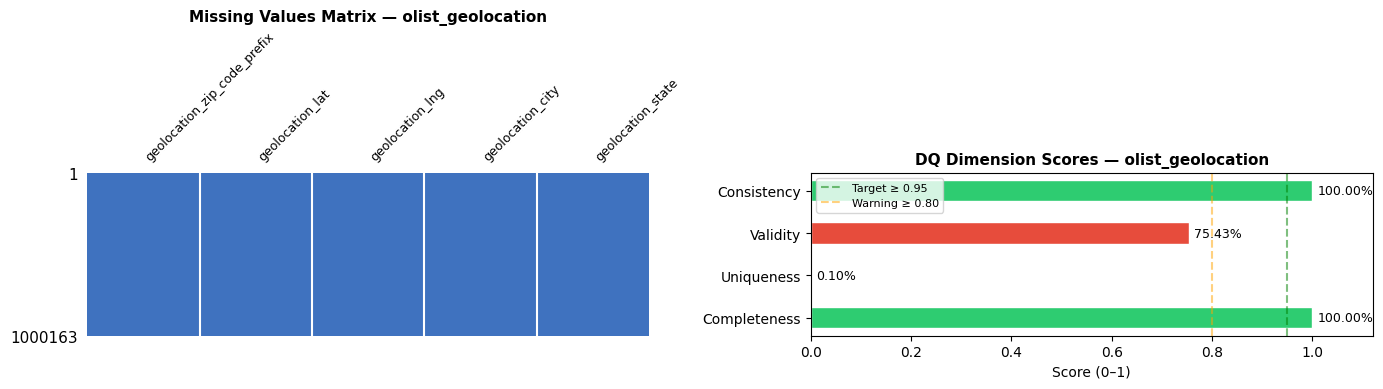

In [18]:
validity_geo = {
    'geolocation_zip_code_prefix': lambda s: s.astype(str).str.match(r'^\d{5}$'),
    # Brasile: latitudine [-33.75, 5.27], longitudine [-73.99, -34.79]
    'geolocation_lat'            : lambda s: s.between(-33.75, 5.27),
    'geolocation_lng'            : lambda s: s.between(-73.99, -34.79),
    'geolocation_state'          : lambda s: s.isin(BR_STATES),
}

consistency_geo = [
    # lat e lng devono essere entrambi presenti
    lambda df: df['geolocation_lat'].notna() & df['geolocation_lng'].notna(),
]

dqa_geo = (
    DQAReport(df_geo, table_name='olist_geolocation')
    .check_completeness(required_cols=df_geo.columns.tolist())
    .check_uniqueness(key_cols=['geolocation_zip_code_prefix'])
    .check_validity(validity_geo)
    .check_consistency(consistency_geo)
)

sc_geo = dqa_geo.print_scorecard()
plot_scorecard(dqa_geo, df_geo, save_path=PLOT_PATH + 'dq_plot_geolocation.png')
sc_geo.to_csv(BASE_PATH + 'dq_scorecard_geolocation.csv', index=False)


---
## 9️⃣ `product_category_name_translation.csv`

Colonne: `product_category_name`, `product_category_name_english`

In [19]:
df_cat = pd.read_csv(RAW_PATH + 'product_category_name_translation.csv')
# Rimuove eventuale BOM e spazi nei nomi colonna
df_cat.columns = df_cat.columns.str.strip().str.lstrip('\ufeff')
print(f'Shape: {df_cat.shape}')
print(f'Colonne: {df_cat.columns.tolist()}')
df_cat.head(3)


Shape: (71, 2)
Colonne: ['product_category_name', 'product_category_name_english']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



══════════════════════════════════════════════════════════════════════
  📊 PRODUCT_CATEGORY_TRANSLATION  —  Overall DQ Score: 100.00% 🟢
══════════════════════════════════════════════════════════════════════
   Dimension  Score  Issues Status                                                                     Details
Completeness 1.0000       0      🟢                                                         Missing per col: {}
  Uniqueness 1.0000       0      🟢                             Righe duplicate su ['product_category_name']: 0
    Validity 1.0000       0      🟢 product_category_name: 0 invalid | product_category_name_english: 0 invalid
 Consistency 1.0000       0      🟢                            0 righe violano almeno una regola di consistenza
──────────────────────────────────────────────────────────────────────

   📁 Plot salvato → c:\Users\ecole\Downloads\provaaa\consegna\5_dq_plots\dq_plot_category_translation.png


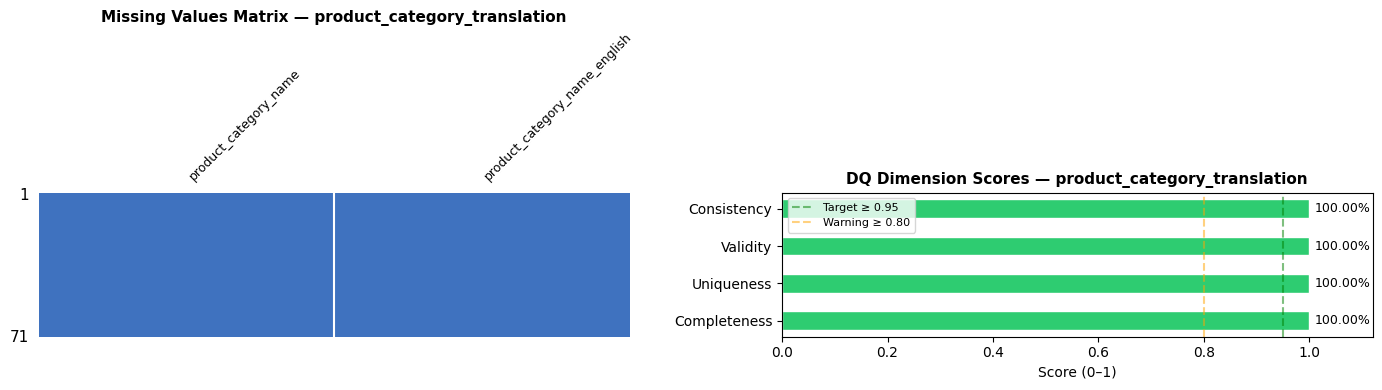

In [20]:
validity_cat = {
    'product_category_name'        : lambda s: s.str.len() > 0,
    'product_category_name_english': lambda s: s.str.len() > 0,
}

consistency_cat = [
    # ogni categoria portoghese deve avere una traduzione inglese
    lambda df: df['product_category_name_english'].notna(),
]

dqa_cat = (
    DQAReport(df_cat, table_name='product_category_translation', primary_key='product_category_name')
    .check_completeness(required_cols=df_cat.columns.tolist())
    .check_uniqueness(key_cols=['product_category_name'])
    .check_validity(validity_cat)
    .check_consistency(consistency_cat)
)

sc_cat = dqa_cat.print_scorecard()
plot_scorecard(dqa_cat, df_cat, save_path=PLOT_PATH + 'dq_plot_category_translation.png')
sc_cat.to_csv(BASE_PATH + 'dq_scorecard_category_translation.csv', index=False)


---
## 🏆 Riepilogo Globale — Multi-Table DQ Comparison

In [21]:
# Raccoglie tutti gli scorecard in un unico DataFrame
all_scorecards = [
    sc_orders, sc_customers, sc_items, sc_payments,
    sc_reviews, sc_products, sc_sellers, sc_geo, sc_cat
]
all_dqa = [
    dqa_orders, dqa_customers, dqa_items, dqa_payments,
    dqa_reviews, dqa_products, dqa_sellers, dqa_geo, dqa_cat
]

combined = pd.concat(all_scorecards, ignore_index=True)

# Overall score per tabella
print(f"{'═'*65}")
print(f"  🏆  OVERALL DQ SCORE — TUTTE LE TABELLE")
print(f"{'═'*65}")
for dqa in all_dqa:
    score   = dqa.overall_score()
    emoji   = '🟢' if score >= 0.95 else ('🟡' if score >= 0.80 else '🔴')
    print(f"  {emoji}  {dqa.table_name:<35} {score:.2%}")
print(f"{'─'*65}\n")

# Pivot: dimensioni × tabelle
pivot = combined.pivot_table(index='Dimension', columns='Table', values='Score')
print("\n📊 PIVOT — Score per Dimensione × Tabella:\n")
print(pivot.round(4).to_string())

# Salva il confronto globale
combined.to_csv(BASE_PATH + 'dq_scorecard_ALL.csv', index=False)
pivot.to_csv(BASE_PATH + 'dq_pivot_comparison.csv')
print("\n✅ File salvati:\n   dq_scorecard_ALL.csv\n   dq_pivot_comparison.csv")


═════════════════════════════════════════════════════════════════
  🏆  OVERALL DQ SCORE — TUTTE LE TABELLE
═════════════════════════════════════════════════════════════════
  🟢  olist_orders                        99.27%
  🟡  olist_customers                     93.97%
  🟢  olist_order_items                   99.65%
  🟢  olist_order_payments                99.65%
  🟢  olist_order_reviews                 99.68%
  🟢  olist_products                      99.25%
  🟡  olist_sellers                       91.71%
  🔴  olist_geolocation                   68.88%
  🟢  product_category_translation        100.00%
─────────────────────────────────────────────────────────────────


📊 PIVOT — Score per Dimensione × Tabella:

Table         olist_customers  olist_geolocation  olist_order_items  olist_order_payments  olist_order_reviews  olist_orders  olist_products  olist_sellers  product_category_translation
Dimension                                                                                        

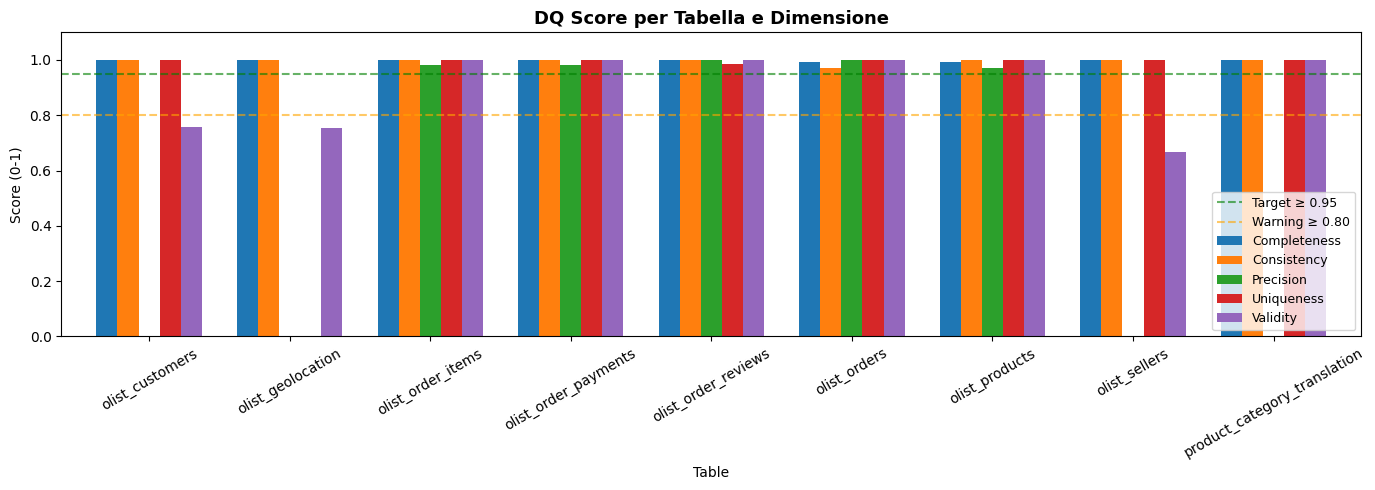

📁 Plot salvato → c:\Users\ecole\Downloads\provaaa\consegna\5_dq_plots\dq_comparison_ALL.png


In [22]:
# ── Grafico comparativo multi-tabella ─────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
pivot_t = pivot.T  # tabelle sulle righe, dimensioni sulle colonne
pivot_t.plot(kind='bar', ax=ax, width=0.75, rot=30)

ax.set_title('DQ Score per Tabella e Dimensione', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (0-1)')
ax.set_ylim(0, 1.1)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.6, label='Target ≥ 0.95')
ax.axhline(0.80, color='orange', linestyle='--', alpha=0.6, label='Warning ≥ 0.80')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()

save_path = PLOT_PATH + 'dq_comparison_ALL.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'📁 Plot salvato → {save_path}')
